In [1]:
#Necessary imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report

In [15]:
df = pd.read_csv("../output/gpt_ner_2026-07-12_14-03-37.csv")
df.head()

,Unnamed: 0,doc_id,sent_id,tok_id,token,lid,borrowed_suffix,ner,gpt_langid
0,0,post_0001,1,0,yabancı,TR,NaN,NaN,TR
1,1,post_0001,1,1,bir,TR,NaN,NaN,TR
2,2,post_0001,1,2,hocamızın,TR,NaN,NaN,TR
3,3,post_0001,1,3,yarı,TR,NaN,NaN,TR
4,4,post_0001,1,4,şaka,TR,NaN,NaN,TR


In [19]:
df["gpt_ner"].value_counts()

gpt_ner
O          4296
B-OTHER     104
B-PROD       98
B-TITLE      60
B-ORG        57
I-TITLE      47
B-PER        32
I-OTHER      25
B-LOC        23
I-PROD       22
I-PER        19
B-GROUP      19
B-TIME       15
I-ORG        11
I-EVENT      11
I-LOC         4
B-EVENT       3
I-GROUP       2
Name: count, dtype: int64

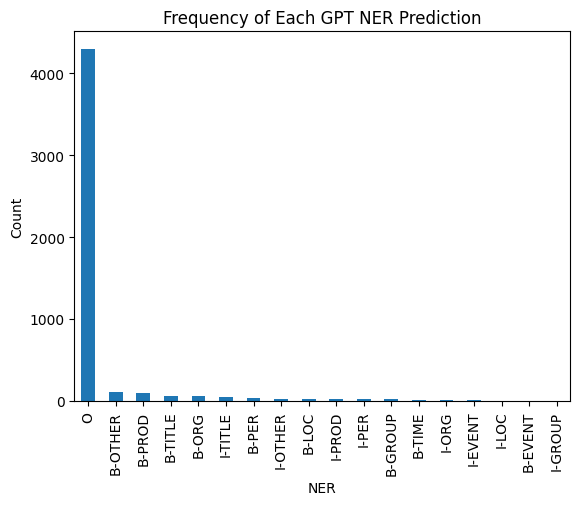

In [20]:
#Frequency of predictions
df['gpt_ner'].value_counts().plot(kind='bar')
plt.title('Frequency of Each GPT NER Prediction')
plt.xlabel('NER')
plt.ylabel('Count')
plt.show()

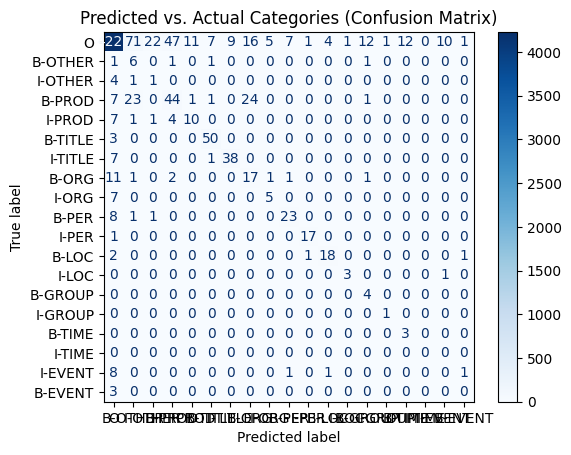

In [26]:
#Confusion matrix
cm = confusion_matrix(df['ner'], df['gpt_ner'], labels=["O", "B-OTHER", "I-OTHER", "B-PROD",
"I-PROD", "B-TITLE", "I-TITLE", "B-ORG", "I-ORG", "B-PER", "I-PER", 
"B-LOC", "I-LOC","B-GROUP", "I-GROUP",
"B-TIME", "I-TIME", "I-EVENT",
"B-EVENT", "UNK"])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["O", "B-OTHER", "I-OTHER", "B-PROD",
"I-PROD", "B-TITLE", "I-TITLE", "B-ORG", "I-ORG", "B-PER", "I-PER", 
"B-LOC", "I-LOC","B-GROUP", "I-GROUP",
"B-TIME", "I-TIME", "I-EVENT",
"B-EVENT", "UNK"])
disp.plot(cmap=plt.cm.Blues)
plt.title("Predicted vs. Actual Categories (Confusion Matrix)")
plt.show()

In [27]:
macro_f1 = f1_score(df["ner"], df["gpt_ner"], average='macro')
print(f"Overall Macro F1 Score: {macro_f1:.4f}\n")

Overall Macro F1 Score: 0.5031



In [28]:
#F1 Per Class
f1_per_class = f1_score(df["ner"], df["gpt_ner"], average=None)
print(f"F1 Score per Class: {f1_per_class}\n")

F1 Score per Class: [0.         0.34782609 0.8        0.37362637 0.10526316 0.70769231
 0.44221106 0.33333333 0.88495575 0.         0.66666667 0.75
 0.43478261 0.06451613 0.91891892 0.44444444 0.8172043  0.96506849]



In [29]:
#Full Classification Report
print("Classification Report:")
print(classification_report(df["ner"], df["gpt_ner"]))

Classification Report:
              precision    recall  f1-score   support

     B-EVENT       0.00      0.00      0.00         3
     B-GROUP       0.21      1.00      0.35         4
       B-LOC       0.78      0.82      0.80        22
       B-ORG       0.30      0.50      0.37        34
     B-OTHER       0.06      0.60      0.11        10
       B-PER       0.72      0.70      0.71        33
      B-PROD       0.45      0.44      0.44       101
      B-TIME       0.20      1.00      0.33         3
     B-TITLE       0.83      0.94      0.88        53
     I-EVENT       0.00      0.00      0.00        11
     I-GROUP       0.50      1.00      0.67         1
       I-LOC       0.75      0.75      0.75         4
       I-ORG       0.45      0.42      0.43        12
     I-OTHER       0.04      0.17      0.06         6
       I-PER       0.89      0.94      0.92        18
      I-PROD       0.45      0.43      0.44        23
     I-TITLE       0.81      0.83      0.82        46
    

In [30]:
mismatched_rows = df[df['ner'] != df['gpt_ner']]

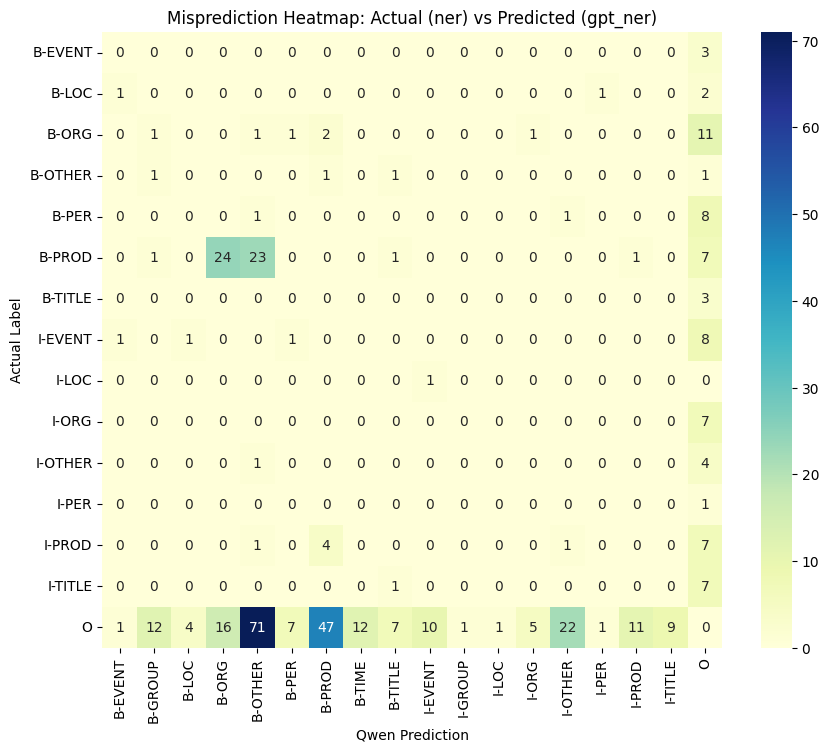

In [31]:
#Mismatched rows CM
confusion_matrix = pd.crosstab(mismatched_rows['ner'], mismatched_rows['gpt_ner'])
plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Misprediction Heatmap: Actual (ner) vs Predicted (gpt_ner)')
plt.ylabel('Actual Label')
plt.xlabel('GPT Prediction')
plt.show()

In [32]:
mismatched_rows

,Unnamed: 0,doc_id,sent_id,tok_id,token,lid,borrowed_suffix,ner,gpt_ner
8,8,post_0001,1,8,university,EN,NaN,O,B-ORG
113,113,post_0004,2,3,pazarlama,TR,NaN,O,B-OTHER
131,131,post_0004,2,25,marketing-mix,EN,NaN,O,B-OTHER
134,134,post_0004,2,28,business,EN,NaN,O,B-OTHER
135,135,post_0004,2,29,development,EN,NaN,O,I-OTHER
...,...,...,...,...,...,...,...,...,...
4759,4759,post_058,1,12,store'dan,MIXED,MIXED,O,I-PROD
4803,4803,post_059,1,4,headhunter,EN,NaN,O,B-OTHER
4804,4804,post_059,1,5,executive,EN,NaN,O,B-OTHER
4805,4805,post_059,1,6,search,EN,NaN,O,I-OTHER
